In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re


In [3]:
df_fake = pd.read_csv("../data/raw/Fake.csv")
df_true = pd.read_csv("../data/raw/True.csv")

# Add labels
df_fake["label"] = 0   # 0 = fake
df_true["label"] = 1   # 1 = true

# Combine into one dataset
df = pd.concat([df_fake, df_true], ignore_index=True)

df.head()



,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [4]:
df.info()
df.columns
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


title      0
text       0
subject    0
date       0
label      0
dtype: int64

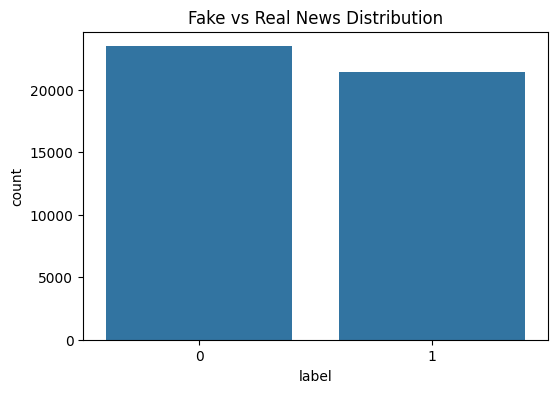

label
0    0.522985
1    0.477015
Name: proportion, dtype: float64

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Fake vs Real News Distribution")
plt.show()

df["label"].value_counts(normalize=True)


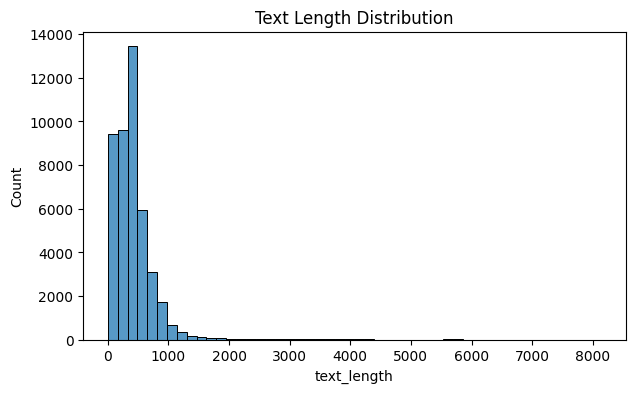

In [6]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
df["text_length"].describe()

plt.figure(figsize=(7,4))
sns.histplot(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text


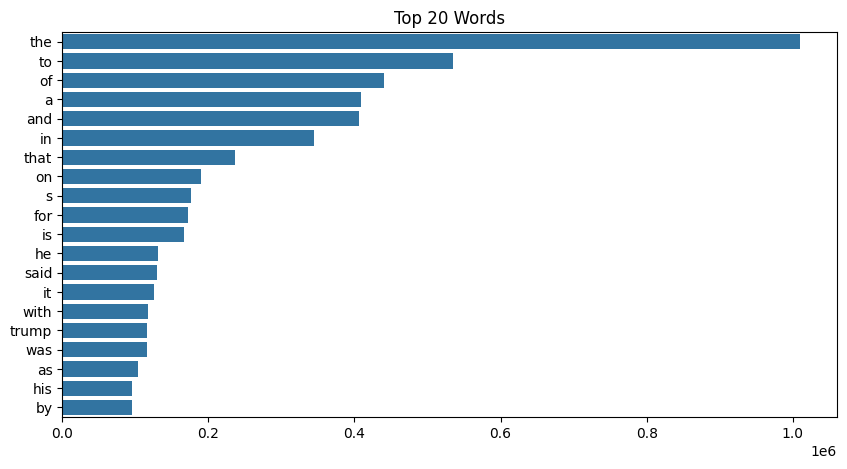

In [8]:
from collections import Counter

all_words = " ".join(df["text"].apply(clean_text)).split()
word_freq = Counter(all_words)

word_freq.most_common(20)

common_words = dict(word_freq.most_common(20))

plt.figure(figsize=(10,5))
sns.barplot(x=list(common_words.values()), y=list(common_words.keys()))
plt.title("Top 20 Words")
plt.show()


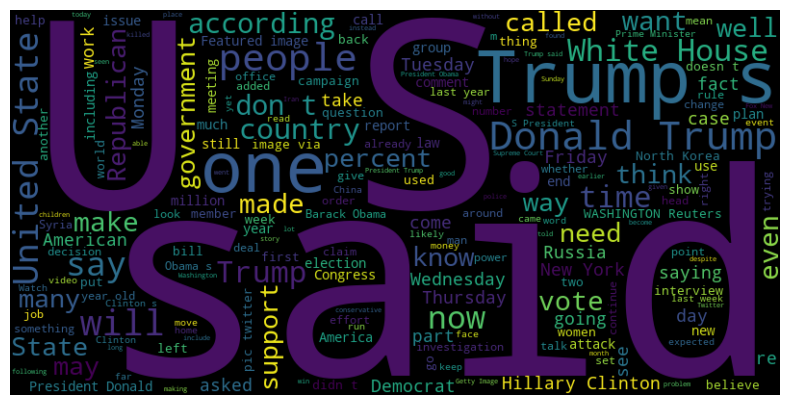

In [9]:
text_string = " ".join(df["text"].astype(str))

wordcloud = WordCloud(width=800, height=400).generate(text_string)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


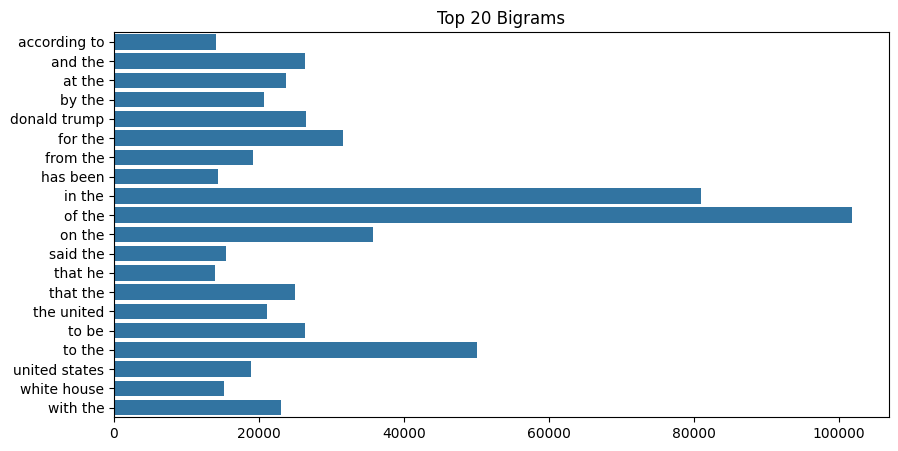

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df["text"].astype(str))

bigrams = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=bigrams)
plt.title("Top 20 Bigrams")
plt.show()



In [11]:
df_clean = df.copy()
df_clean["text"] = df_clean["text"].apply(clean_text)

df_clean.to_csv("../data/processed/news_clean.csv", index=False)


OSError: Cannot save file into a non-existent directory: '..\data\processed'